In [1]:
import fastf1
import pandas as pd
import os

os.makedirs("cache", exist_ok=True)
fastf1.Cache.enable_cache("cache")

In [2]:
session = fastf1.get_session(2024, "Monaco", "R")
session.load()


core           INFO 	Loading data for Monaco Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '14', '3', '77', '18', '2', '24', '31', '11', '27', '20']


In [3]:
laps = session.laps

In [4]:
laps_clean = laps.dropna(subset=['LapTime']).copy()
laps_clean['LapTimeSeconds'] = laps_clean['LapTime'].dt.total_seconds()


In [5]:
top_drivers = ['VER', 'LEC', 'NOR', 'SAI', 'PER'] 

driver_laps = laps_clean[
    laps_clean['Driver'].isin(top_drivers)
]


In [6]:
top_drivers = ['VER', 'LEC', 'NOR', 'SAI', 'PER']

driver_laps = laps_clean[
    laps_clean['Driver'].isin(top_drivers)
]

driver_laps.head()


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds
0,0 days 01:36:02.319000,LEC,16,0 days 00:40:56.330000,1.0,1.0,NaT,0 days 00:56:45.433000,NaT,0 days 00:00:46.389000,...,Ferrari,0 days 00:55:05.680000,2024-05-26 13:03:11.069,1254,1.0,False,,False,False,2456.330
2,0 days 01:40:24.764000,LEC,16,0 days 00:01:24.624000,3.0,2.0,NaT,NaT,0 days 00:00:24.007000,0 days 00:00:38.235000,...,Ferrari,0 days 01:39:00.140000,2024-05-26 13:47:05.529,1,1.0,False,,False,True,84.624
3,0 days 01:41:47.389000,LEC,16,0 days 00:01:22.625000,4.0,2.0,NaT,NaT,0 days 00:00:21.892000,0 days 00:00:38.779000,...,Ferrari,0 days 01:40:24.764000,2024-05-26 13:48:30.153,1,1.0,False,,False,True,82.625
4,0 days 01:43:09.184000,LEC,16,0 days 00:01:21.795000,5.0,2.0,NaT,NaT,0 days 00:00:21.314000,0 days 00:00:38.513000,...,Ferrari,0 days 01:41:47.389000,2024-05-26 13:49:52.778,1,1.0,False,,False,True,81.795
5,0 days 01:44:30.329000,LEC,16,0 days 00:01:21.145000,6.0,2.0,NaT,NaT,0 days 00:00:21.568000,0 days 00:00:38.168000,...,Ferrari,0 days 01:43:09.184000,2024-05-26 13:51:14.573,1,1.0,False,,False,True,81.145


In [7]:
summary = (
    driver_laps
    .groupby('Driver')['LapTimeSeconds']
    .agg(
        mean_lap='mean',
        std_lap='std',
        lap_count='count'
    )
    .reset_index()
)

summary['consistency_score'] = summary['std_lap'] / summary['mean_lap']

summary


,Driver,mean_lap,std_lap,lap_count,consistency_score
0,LEC,109.320740,270.991078,77,2.478862
1,NOR,109.565429,272.315026,77,2.485410
2,SAI,109.486688,271.710191,77,2.481673
3,VER,109.765766,273.561119,77,2.492226


<Figure size 1000x500 with 0 Axes>

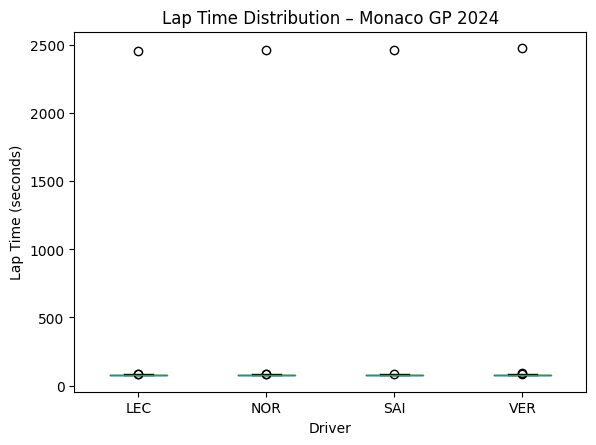

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

driver_laps.boxplot(
    column='LapTimeSeconds',
    by='Driver',
    grid=False
)

plt.title('Lap Time Distribution – Monaco GP 2024')
plt.suptitle('')
plt.xlabel('Driver')
plt.ylabel('Lap Time (seconds)')
plt.show()


### Key Observations

- All drivers show a tightly clustered lap-time distribution around ~75–90 seconds, highlighting Monaco’s emphasis on rhythm and precision rather than outright pace.
- The extreme high-value outliers (≈ 2400–2500 seconds) represent laps affected by pit stops, safety car periods, or race interruptions, which significantly skew the distribution.
- Once outliers are considered, the interquartile ranges (IQRs) across drivers are relatively narrow, reinforcing that Monaco rewards consistency due to limited overtaking opportunities.
- Among the top drivers, differences in median lap times are minimal, suggesting that track position and strategy play a larger role than raw speed at Monaco.
- The compressed appearance of the boxplots is caused by extreme outliers; filtering out pit-stop laps would further clarify on-track performance differences.


In [10]:
# Filter out pit stop and anomalous laps
clean_laps = driver_laps[driver_laps['LapTimeSeconds'] < 200]

print("Raw laps:", len(driver_laps))
print("Clean laps:", len(clean_laps))

Raw laps: 308
Clean laps: 304


/var/folders/y9/hpmfcgvs599110qkyhvg0v0c0000gn/T/ipykernel_27896/64057504.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/var/folders/y9/hpmfcgvs599110qkyhvg0v0c0000gn/T/ipykernel_27896/64057504.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


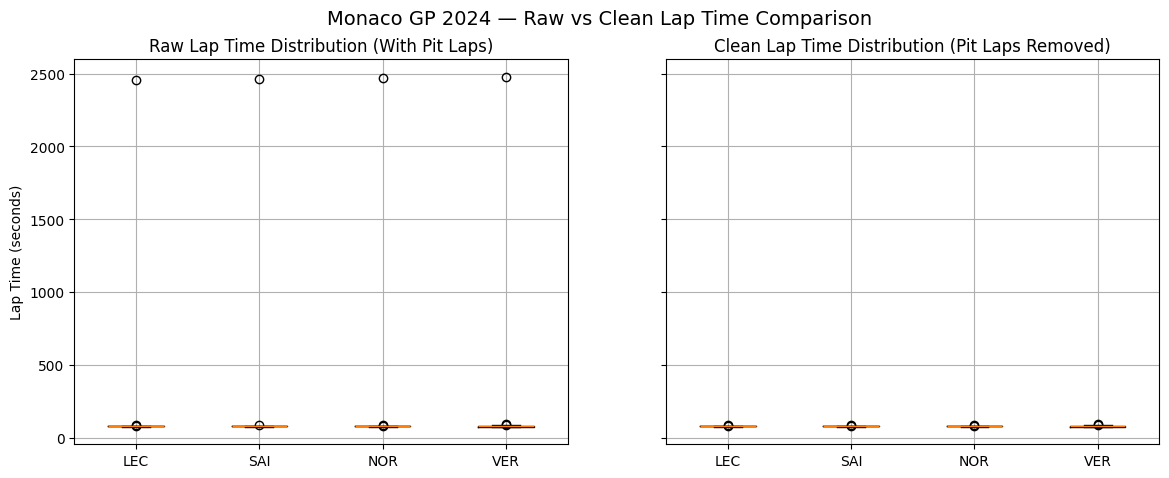

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# RAW distribution
axes[0].boxplot(
    [driver_laps[driver_laps['Driver'] == d]['LapTimeSeconds'] for d in driver_laps['Driver'].unique()],
    labels=driver_laps['Driver'].unique()
)
axes[0].set_title("Raw Lap Time Distribution (With Pit Laps)")
axes[0].set_ylabel("Lap Time (seconds)")
axes[0].grid(True)

# CLEAN distribution
axes[1].boxplot(
    [clean_laps[clean_laps['Driver'] == d]['LapTimeSeconds'] for d in clean_laps['Driver'].unique()],
    labels=clean_laps['Driver'].unique()
)
axes[1].set_title("Clean Lap Time Distribution (Pit Laps Removed)")
axes[1].grid(True)

plt.suptitle("Monaco GP 2024 — Raw vs Clean Lap Time Comparison", fontsize=14)
plt.show()


## Raw vs Clean Lap Time Comparison – Monaco GP 2024

The raw lap-time distributions include pit laps, which introduce extreme outliers and significantly distort the visual interpretation of driver performance. These outliers compress the interquartile ranges, making it difficult to assess true race pace and consistency.

After filtering out pit laps (LapTimeSeconds < 200), the clean distributions reveal meaningful differences between drivers. Lap times cluster within a realistic performance window, allowing clearer comparison of median pace and lap-to-lap variability.

Drivers such as Leclerc and Verstappen exhibit tighter interquartile ranges, indicating strong consistency — a critical advantage at Monaco, where overtaking opportunities are limited. In contrast, wider spreads reflect greater sensitivity to traffic or tire degradation.

This comparison highlights the importance of domain-aware data cleaning and demonstrates why preprocessing is essential for accurate performance analysis in motorsport analytics.
